In [1]:
!pip -q install timm transformers umap-learn

In [3]:
from pathlib import Path
import sys, gc, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2, InterpolationMode
from transformers import AutoModel, AutoImageProcessor
from umap import UMAP

from io import BytesIO
from IPython.display import display, Image as IPyImage

REPO_DIR = "/path/to/VECA"
CKPT_PATH = "/path/to/checkpoint.pt"
IMAGE_PATH = "/path/to/image.jpg"

RESOLUTIONS = [256, 384, 512, 768, 1024]
ACTIVE_K = 64
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

sys.path.insert(0, REPO_DIR)

assert Path(REPO_DIR).exists(), REPO_DIR
assert Path(CKPT_PATH).exists(), CKPT_PATH
assert Path(IMAGE_PATH).exists(), IMAGE_PATH

device = torch.device(DEVICE)
print("device:", device)


device: cuda:0


In [4]:
from veca.model import VECA
from veca.config import MultiResFinetuneConfig

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def display_fig_as_jpeg(fig, quality=90, dpi=150):
    buf = BytesIO()
    fig.savefig(
        buf,
        format="jpeg",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
        pil_kwargs={"quality": quality, "optimize": True},
    )
    buf.seek(0)
    display(IPyImage(data=buf.getvalue(), format="jpeg"))
    plt.close(fig)

def clean_state_dict(state):
    out = {}
    for k, v in state.items():
        if k.startswith("module."):
            k = k[len("module."):]
        if k.startswith("student."):
            k = k[len("student."):]
        out[k] = v
    return out

def make_cfg_from_ckpt(ckpt):
    cfg = MultiResFinetuneConfig()
    ckpt_cfg = ckpt.get("config", {}) if isinstance(ckpt, dict) else {}

    for k, v in ckpt_cfg.items():
        if hasattr(cfg, k):
            setattr(cfg, k, v)

    cfg.model_family = "base"
    cfg.num_query_tokens = 64
    cfg.hidden_dim = 768
    cfg.num_heads = 12
    cfg.num_layers = 12
    cfg.mlp_ratio = 2.66667
    cfg.patch_size = 16
    cfg.nested_chunk_size = 8

    cfg.init_patch_from_dinov3 = False
    return cfg

def load_ours(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    state = ckpt["student"] if isinstance(ckpt, dict) and "student" in ckpt else ckpt
    state = clean_state_dict(state)

    cfg = make_cfg_from_ckpt(ckpt if isinstance(ckpt, dict) else {})
    model = VECA(cfg)
    missing, unexpected = model.load_state_dict(state, strict=False)

    if missing:
        print("[ours] missing:", missing)
    if unexpected:
        print("[ours] unexpected:", unexpected)

    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model

ours_model = load_ours(CKPT_PATH)
print("loaded ours")


loaded ours


In [7]:
MODEL_SPECS = {
    "ours_b": {
        "label": "Ours-B K=64",
        "kind": "ours",
        "patch_size": 16,
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD,
    },
    "dinov3_b": {
        "label": "DINOv3-B",
        "kind": "hf_vit",
        "repo": "facebook/dinov3-vitb16-pretrain-lvd1689m",
        "patch_size": 16,
    },
    "dinov2_reg_b": {
        "label": "DINOv2-Reg-B",
        "kind": "hf_vit",
        "repo": "facebook/dinov2-with-registers-base",
        "patch_size": 14,
    },
    "dinov2_b": {
        "label": "DINOv2-B",
        "kind": "hf_vit",
        "repo": "facebook/dinov2-base",
        "patch_size": 14,
    },
    "clearclip_b16": {
        "label": "ClearCLIP-B/16",
        "kind": "clearclip",
        "repo": "openai/clip-vit-base-patch16",
        "patch_size": 16,
    },
}

MODELS = ["ours_b", "dinov3_b", "dinov2_reg_b", "dinov2_b", "clearclip_b16"]

loaded_models = {"ours_b": ours_model}

for name in MODELS:
    if name == "ours_b":
        continue
    repo = MODEL_SPECS[name]["repo"]
    print("loading", name, repo)
    model = AutoModel.from_pretrained(repo).to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    loaded_models[name] = model

print("all models loaded")


loading dinov3_b facebook/dinov3-vitb16-pretrain-lvd1689m


config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

loading dinov2_reg_b facebook/dinov2-with-registers-base


...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


all models loaded


In [8]:
def to_3tuple(x, default):
    if x is None:
        return default
    return tuple(float(v) for v in x)

def get_processor_mean_std(spec):
    if "mean" in spec and "std" in spec:
        return spec["mean"], spec["std"]

    try:
        proc = AutoImageProcessor.from_pretrained(spec["repo"], use_fast=True)
    except Exception:
        proc = AutoImageProcessor.from_pretrained(spec["repo"])

    mean = to_3tuple(getattr(proc, "image_mean", None), IMAGENET_MEAN)
    std = to_3tuple(getattr(proc, "image_std", None), IMAGENET_STD)
    return mean, std

norm_stats = {
    name: get_processor_mean_std(MODEL_SPECS[name])
    for name in MODELS
}

def make_image_transform(resolution, mean, std):
    resize_short = int(round(resolution * 1.125))
    return v2.Compose([
        v2.ToImage(),
        v2.Resize(resize_short, interpolation=InterpolationMode.BICUBIC, antialias=True),
        v2.CenterCrop(resolution),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=mean, std=std),
    ])

def make_raw_transform(resolution):
    resize_short = int(round(resolution * 1.125))
    return v2.Compose([
        v2.ToImage(),
        v2.Resize(resize_short, interpolation=InterpolationMode.BICUBIC, antialias=True),
        v2.CenterCrop(resolution),
        v2.ToDtype(torch.float32, scale=True),
    ])

def load_image_for_model(path, resolution, mean, std):
    with Image.open(path) as im:
        img = im.convert("RGB")

    x = make_image_transform(resolution, mean, std)(img).unsqueeze(0)
    raw = make_raw_transform(resolution)(img).permute(1, 2, 0).numpy()
    raw = (raw * 255).clip(0, 255).astype(np.uint8)
    return x, raw

def amp_context(x):
    if x.is_cuda:
        return torch.autocast(device_type="cuda", dtype=torch.bfloat16)
    from contextlib import nullcontext
    return nullcontext()


preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

In [9]:
@torch.no_grad()
def extract_ours_features(model, x, active_k):
    with amp_context(x):
        cls, patches = model(x, active_k=active_k)
    Hp = x.shape[-2] // 16
    Wp = x.shape[-1] // 16
    return cls[0].float().cpu().numpy(), patches[0].float().cpu().numpy(), (Hp, Wp)

@torch.no_grad()
def extract_hf_vit_features(model, x, patch_size):
    with amp_context(x):
        try:
            out = model(pixel_values=x, return_dict=True, interpolate_pos_encoding=True)
        except TypeError:
            out = model(pixel_values=x, return_dict=True)

    tokens = out.last_hidden_state
    Hp = x.shape[-2] // patch_size
    Wp = x.shape[-1] // patch_size
    expected = Hp * Wp

    cls = tokens[:, 0, :]
    patches = tokens[:, -expected:, :]
    return cls[0].float().cpu().numpy(), patches[0].float().cpu().numpy(), (Hp, Wp)

def call_clip_encoder_layer(layer, hidden_states):
    try:
        out = layer(hidden_states, attention_mask=None, causal_attention_mask=None, output_attentions=False)
    except TypeError:
        try:
            out = layer(hidden_states, None, None, False)
        except TypeError:
            out = layer(hidden_states, output_attentions=False)
    return out[0] if isinstance(out, tuple) else out

def clip_embeddings_forward(vision, x):
    try:
        return vision.embeddings(pixel_values=x, interpolate_pos_encoding=True)
    except TypeError:
        try:
            return vision.embeddings(x, interpolate_pos_encoding=True)
        except TypeError:
            return vision.embeddings(x)

def custom_clip_attn(attn_layer, x):
    B, L, C = x.shape
    H = attn_layer.num_heads
    Hd = C // H
    scale = Hd ** -0.5

    q = attn_layer.q_proj(x)
    v = attn_layer.v_proj(x)

    q = q.view(B, L, H, Hd).transpose(1, 2).reshape(B * H, L, Hd)
    v = v.view(B, L, H, Hd).transpose(1, 2).reshape(B * H, L, Hd)

    attn_logits = torch.bmm(q, q.transpose(1, 2)) * scale
    attn_weights = F.softmax(attn_logits, dim=-1)
    attn_output = torch.bmm(attn_weights, v)

    attn_output = attn_output.view(B, H, L, Hd).transpose(1, 2).reshape(B, L, C)
    return attn_layer.out_proj(attn_output)

@torch.no_grad()
def extract_clearclip_features(model, x, patch_size):
    vision = model.vision_model if hasattr(model, "vision_model") else model
    visual_projection = getattr(model, "visual_projection", None)

    with amp_context(x):
        hidden_states = clip_embeddings_forward(vision, x)

        if hasattr(vision, "pre_layrnorm"):
            hidden_states = vision.pre_layrnorm(hidden_states)
        elif hasattr(vision, "pre_layernorm"):
            hidden_states = vision.pre_layernorm(hidden_states)

        layers = vision.encoder.layers

        for layer in layers[:-1]:
            hidden_states = call_clip_encoder_layer(layer, hidden_states)

        normed = layers[-1].layer_norm1(hidden_states)
        clearclip_tokens = custom_clip_attn(layers[-1].self_attn, normed)
        normal_tokens = call_clip_encoder_layer(layers[-1], hidden_states)

        if hasattr(vision, "post_layernorm"):
            clearclip_tokens = vision.post_layernorm(clearclip_tokens)
            cls = vision.post_layernorm(normal_tokens[:, 0, :])
        else:
            cls = normal_tokens[:, 0, :]

        Hp = x.shape[-2] // patch_size
        Wp = x.shape[-1] // patch_size
        expected = Hp * Wp
        patches = clearclip_tokens[:, -expected:, :]

        if visual_projection is not None:
            cls = visual_projection(cls)
            patches = visual_projection(patches)

    return cls[0].float().cpu().numpy(), patches[0].float().cpu().numpy(), (Hp, Wp)

def extract_features(name, model, x):
    spec = MODEL_SPECS[name]
    if spec["kind"] == "ours":
        return extract_ours_features(model, x, ACTIVE_K)
    if spec["kind"] == "hf_vit":
        return extract_hf_vit_features(model, x, spec["patch_size"])
    if spec["kind"] == "clearclip":
        return extract_clearclip_features(model, x, spec["patch_size"])
    raise ValueError(name)


In [10]:
def l2_normalize(feats):
    norms = np.linalg.norm(feats, axis=-1, keepdims=True)
    return feats / np.maximum(norms, 1e-8)

def normalize_umap_rgb(embedding):
    out = np.zeros_like(embedding, dtype=np.float32)
    for c in range(3):
        lo, hi = embedding[:, c].min(), embedding[:, c].max()
        out[:, c] = (embedding[:, c] - lo) / max(hi - lo, 1e-8)
    return out

def fit_joint_umap_rgb_by_resolution(patches_by_res, grids_by_res, resolutions, seed=0):
    feats_list = [patches_by_res[res].astype(np.float32) for res in resolutions]
    counts = [x.shape[0] for x in feats_list]
    feats_all = l2_normalize(np.concatenate(feats_list, axis=0))

    reducer = UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=seed,
    )

    rgb_all = normalize_umap_rgb(reducer.fit_transform(feats_all))

    out = {}
    start = 0
    for res, count in zip(resolutions, counts):
        Hp, Wp = grids_by_res[res]
        out[res] = rgb_all[start:start + count].reshape(Hp, Wp, 3)
        start += count
    return out

def cls_dense_cosine_similarity(global_feat, patch_feats):
    global_norm = global_feat / max(np.linalg.norm(global_feat), 1e-8)
    patch_normed = patch_feats / np.maximum(np.linalg.norm(patch_feats, axis=-1, keepdims=True), 1e-8)
    return patch_normed @ global_norm

def upsample_rgb(arr, size_hw):
    h, w = size_hw
    arr_u8 = (arr * 255).clip(0, 255).astype(np.uint8)
    return np.array(Image.fromarray(arr_u8).resize((w, h), Image.NEAREST))

def plot_resolution(raw, results, resolution):
    n = len(MODELS)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.0 * n))

    if n == 1:
        axes = axes[None, :]

    for r, name in enumerate(MODELS):
        item = results[name]
        label = MODEL_SPECS[name]["label"]

        umap_up = upsample_rgb(item["umap"], raw.shape[:2])
        overlay = (0.35 * raw.astype(np.float32) + 0.65 * umap_up.astype(np.float32)).clip(0, 255).astype(np.uint8)

        cos = item["cos_sim"]
        cos_norm = (cos - cos.min()) / max(cos.max() - cos.min(), 1e-8)

        axes[r, 0].imshow(umap_up)
        axes[r, 0].set_ylabel(label, fontweight="bold")
        axes[r, 0].set_title("UMAP" if r == 0 else "")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(overlay)
        axes[r, 1].set_title("Overlay" if r == 0 else "")
        axes[r, 1].axis("off")

        im = axes[r, 2].imshow(cos_norm, cmap="viridis", vmin=0, vmax=1)
        axes[r, 2].set_title("CLS-Patch CosSim" if r == 0 else "")
        axes[r, 2].axis("off")

    fig.suptitle(f"Resolution {resolution}", fontweight="bold")
    plt.tight_layout()
    display_fig_as_jpeg(fig, quality=90, dpi=150)


In [11]:
image_path = Path(IMAGE_PATH)
assert image_path.exists(), image_path

feature_cache = {name: {} for name in MODELS}
raw_by_res = {}

for res in RESOLUTIONS:
    print(f"\nresolution {res}")

    for name in MODELS:
        spec = MODEL_SPECS[name]
        mean, std = norm_stats[name]

        x, raw = load_image_for_model(image_path, res, mean, std)
        x = x.to(device, non_blocking=True)

        if res not in raw_by_res:
            raw_by_res[res] = raw

        global_np, patches_np, grid = extract_features(name, loaded_models[name], x)

        cos_sim = cls_dense_cosine_similarity(global_np, patches_np).reshape(grid)

        feature_cache[name][res] = {
            "global": global_np,
            "patches": patches_np,
            "grid": grid,
            "cos_sim": cos_sim,
        }

        print(f"  {spec['label']}: patches={patches_np.shape}, grid={grid}")

        del x
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

all_results = {res: {} for res in RESOLUTIONS}

print("\nFitting joint UMAP across resolutions per model...")
for model_idx, name in enumerate(MODELS):
    patches_by_res = {res: feature_cache[name][res]["patches"] for res in RESOLUTIONS}
    grids_by_res = {res: feature_cache[name][res]["grid"] for res in RESOLUTIONS}

    umap_by_res = fit_joint_umap_rgb_by_resolution(
        patches_by_res,
        grids_by_res,
        RESOLUTIONS,
        seed=model_idx * 100,
    )

    for res in RESOLUTIONS:
        all_results[res][name] = {
            "umap": umap_by_res[res],
            "cos_sim": feature_cache[name][res]["cos_sim"],
        }

print("done")



resolution 256
  Ours-B K=64: patches=(256, 768), grid=(16, 16)
  DINOv3-B: patches=(256, 768), grid=(16, 16)
  DINOv2-Reg-B: patches=(324, 768), grid=(18, 18)
  DINOv2-B: patches=(324, 768), grid=(18, 18)
  ClearCLIP-B/16: patches=(256, 512), grid=(16, 16)

resolution 384
  Ours-B K=64: patches=(576, 768), grid=(24, 24)
  DINOv3-B: patches=(576, 768), grid=(24, 24)
  DINOv2-Reg-B: patches=(729, 768), grid=(27, 27)
  DINOv2-B: patches=(729, 768), grid=(27, 27)
  ClearCLIP-B/16: patches=(576, 512), grid=(24, 24)

resolution 512
  Ours-B K=64: patches=(1024, 768), grid=(32, 32)
  DINOv3-B: patches=(1024, 768), grid=(32, 32)
  DINOv2-Reg-B: patches=(1296, 768), grid=(36, 36)
  DINOv2-B: patches=(1296, 768), grid=(36, 36)
  ClearCLIP-B/16: patches=(1024, 512), grid=(32, 32)

resolution 768
  Ours-B K=64: patches=(2304, 768), grid=(48, 48)
  DINOv3-B: patches=(2304, 768), grid=(48, 48)
  DINOv2-Reg-B: patches=(2916, 768), grid=(54, 54)
  DINOv2-B: patches=(2916, 768), grid=(54, 54)
  Clear

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


done


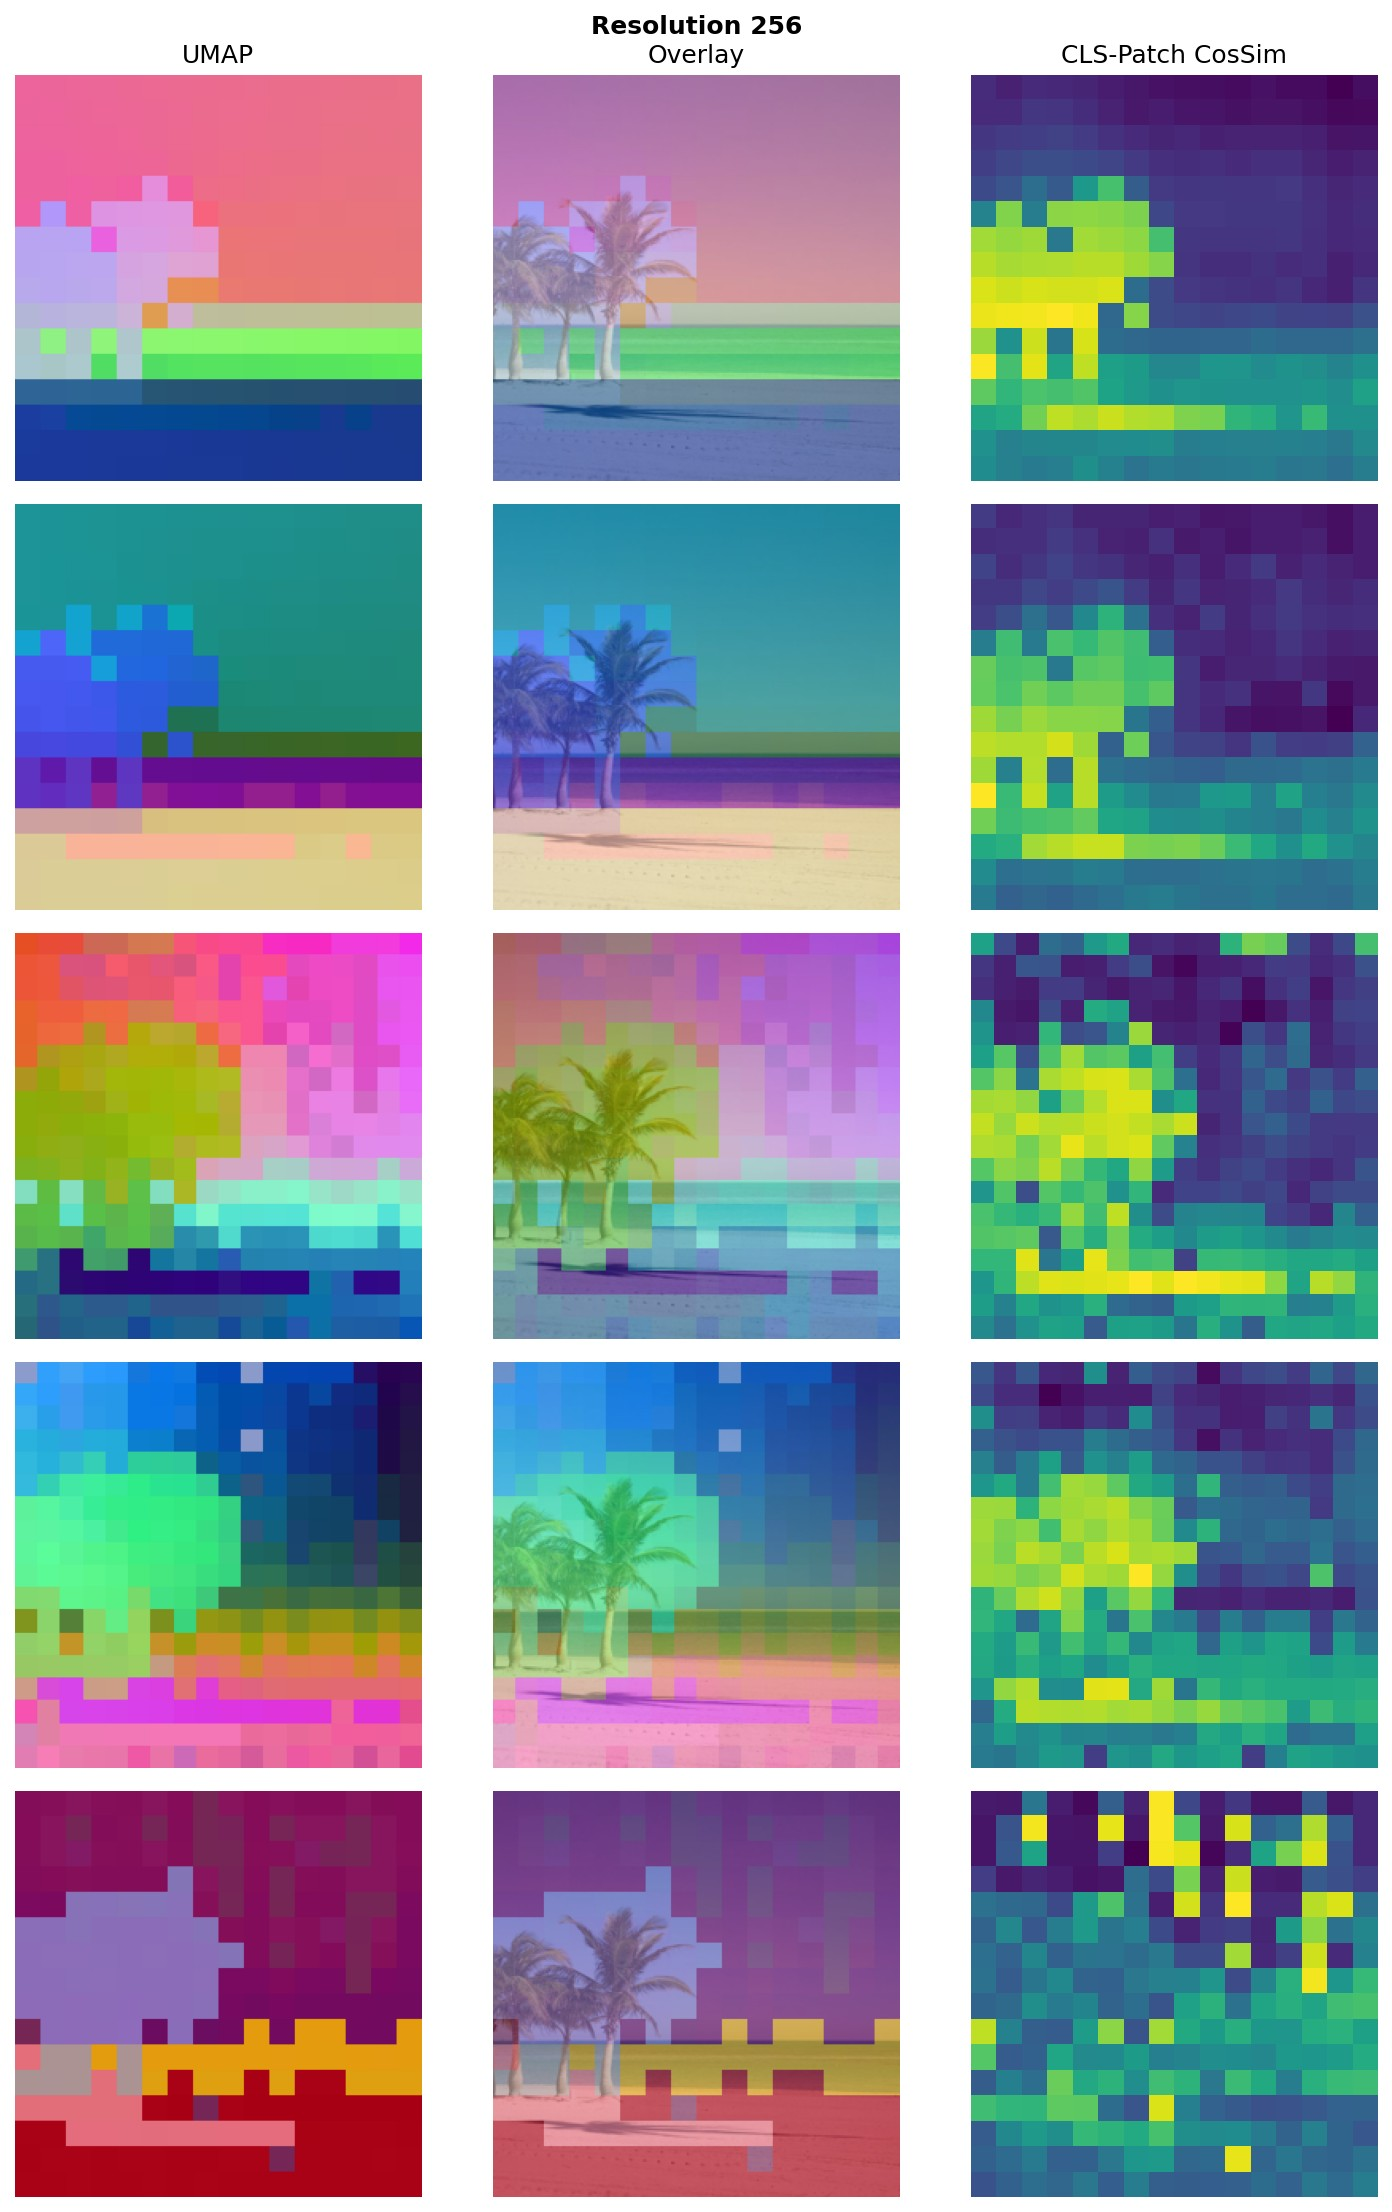

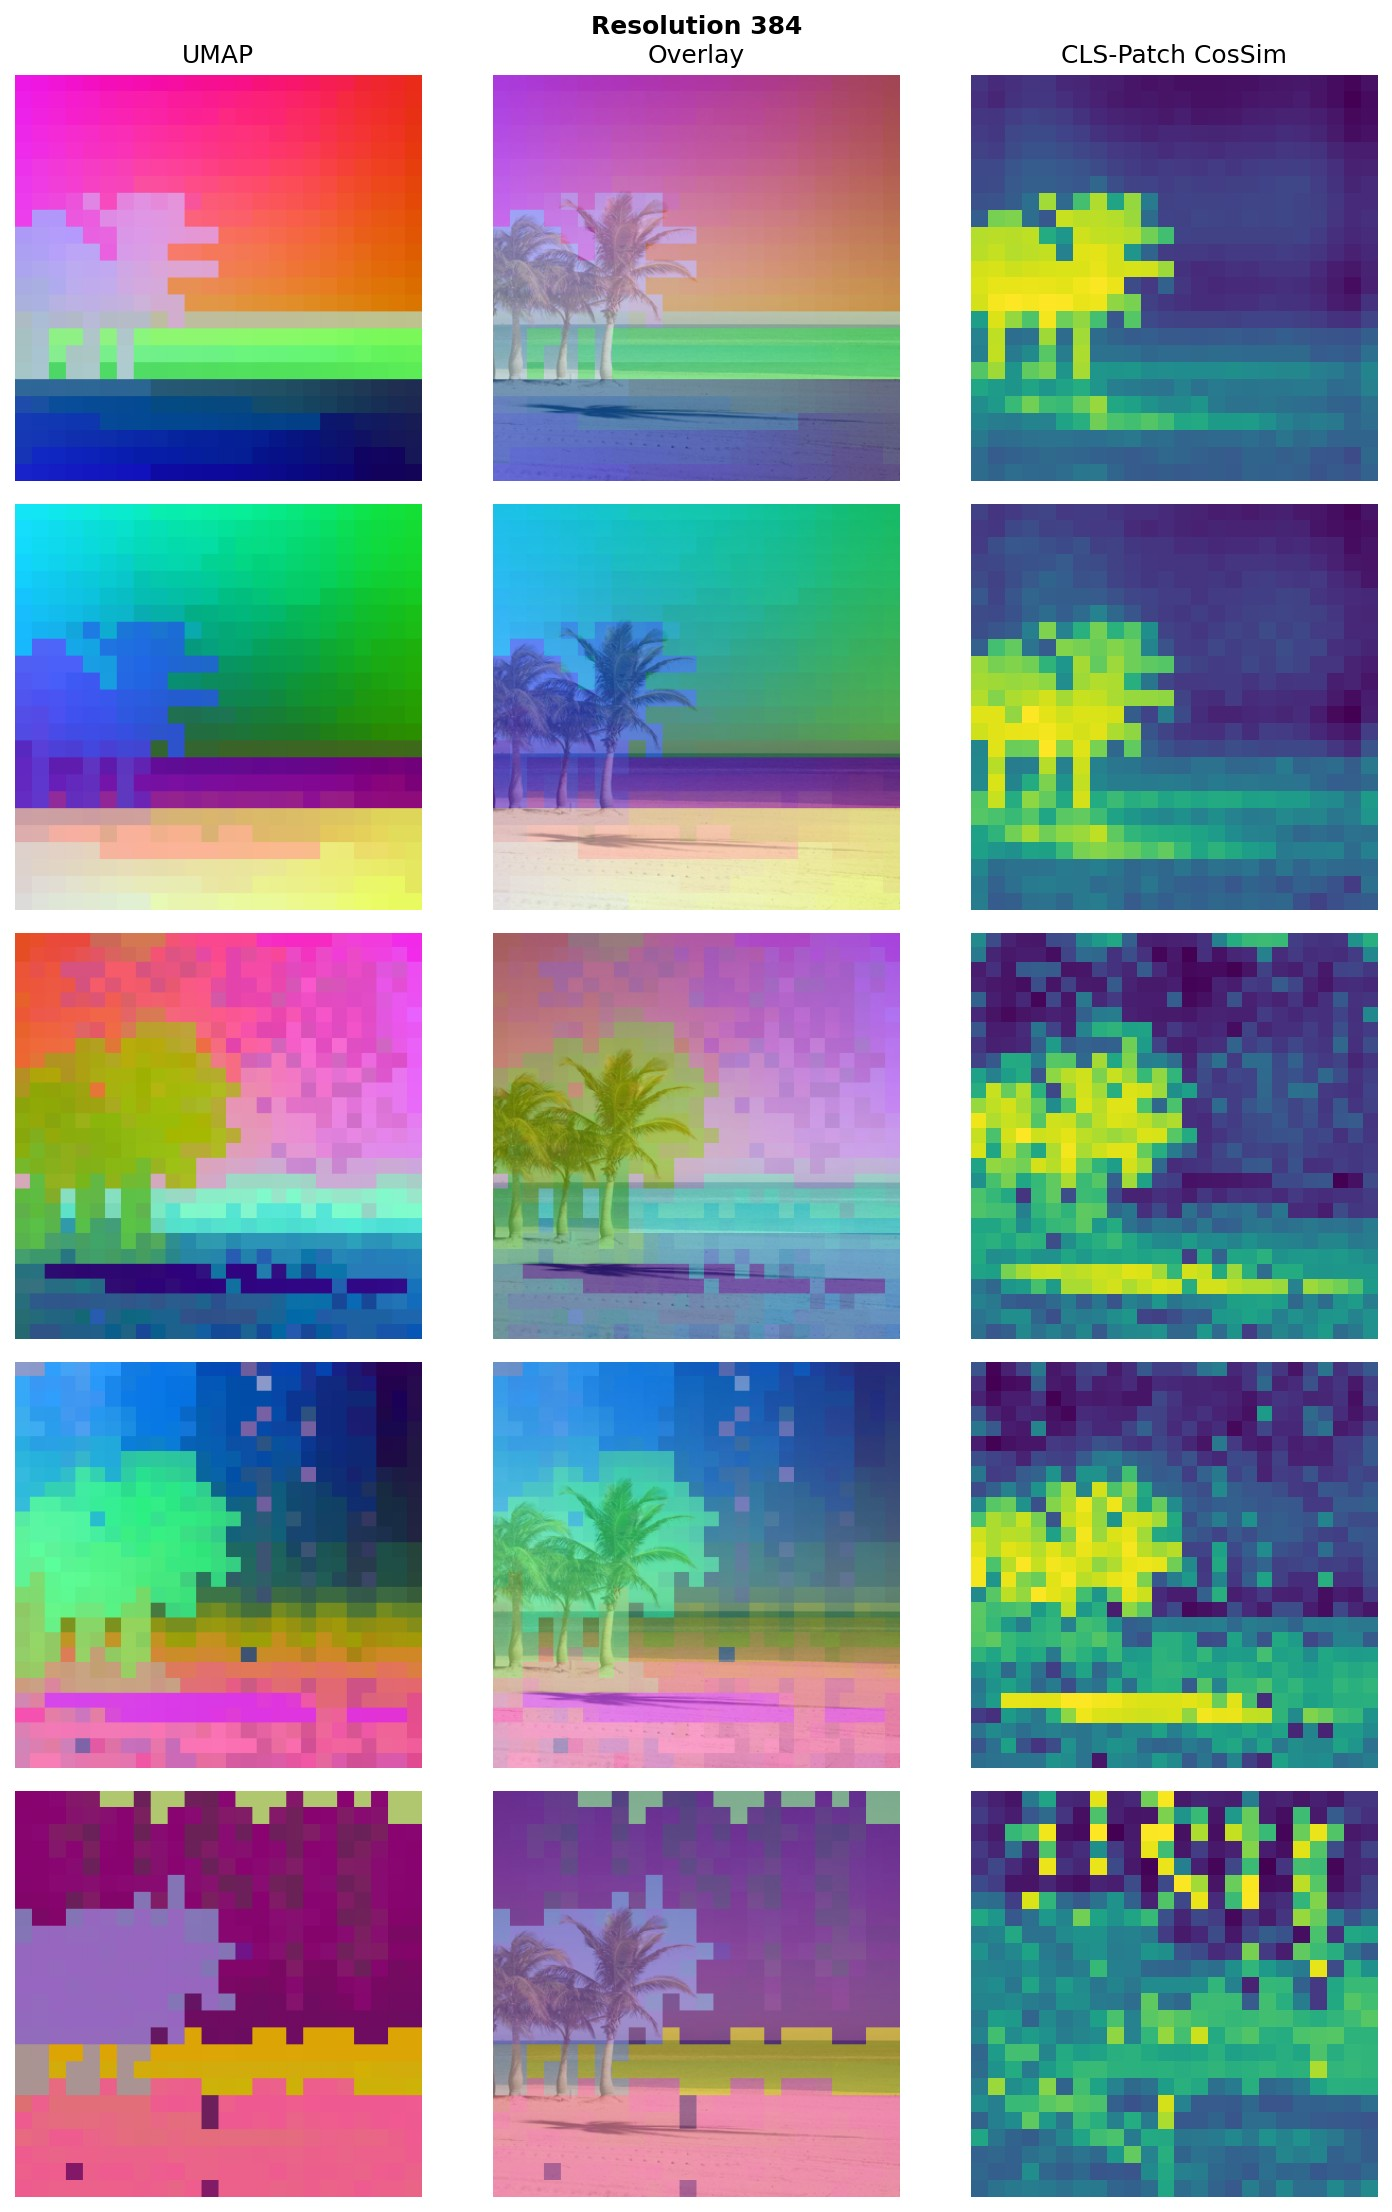

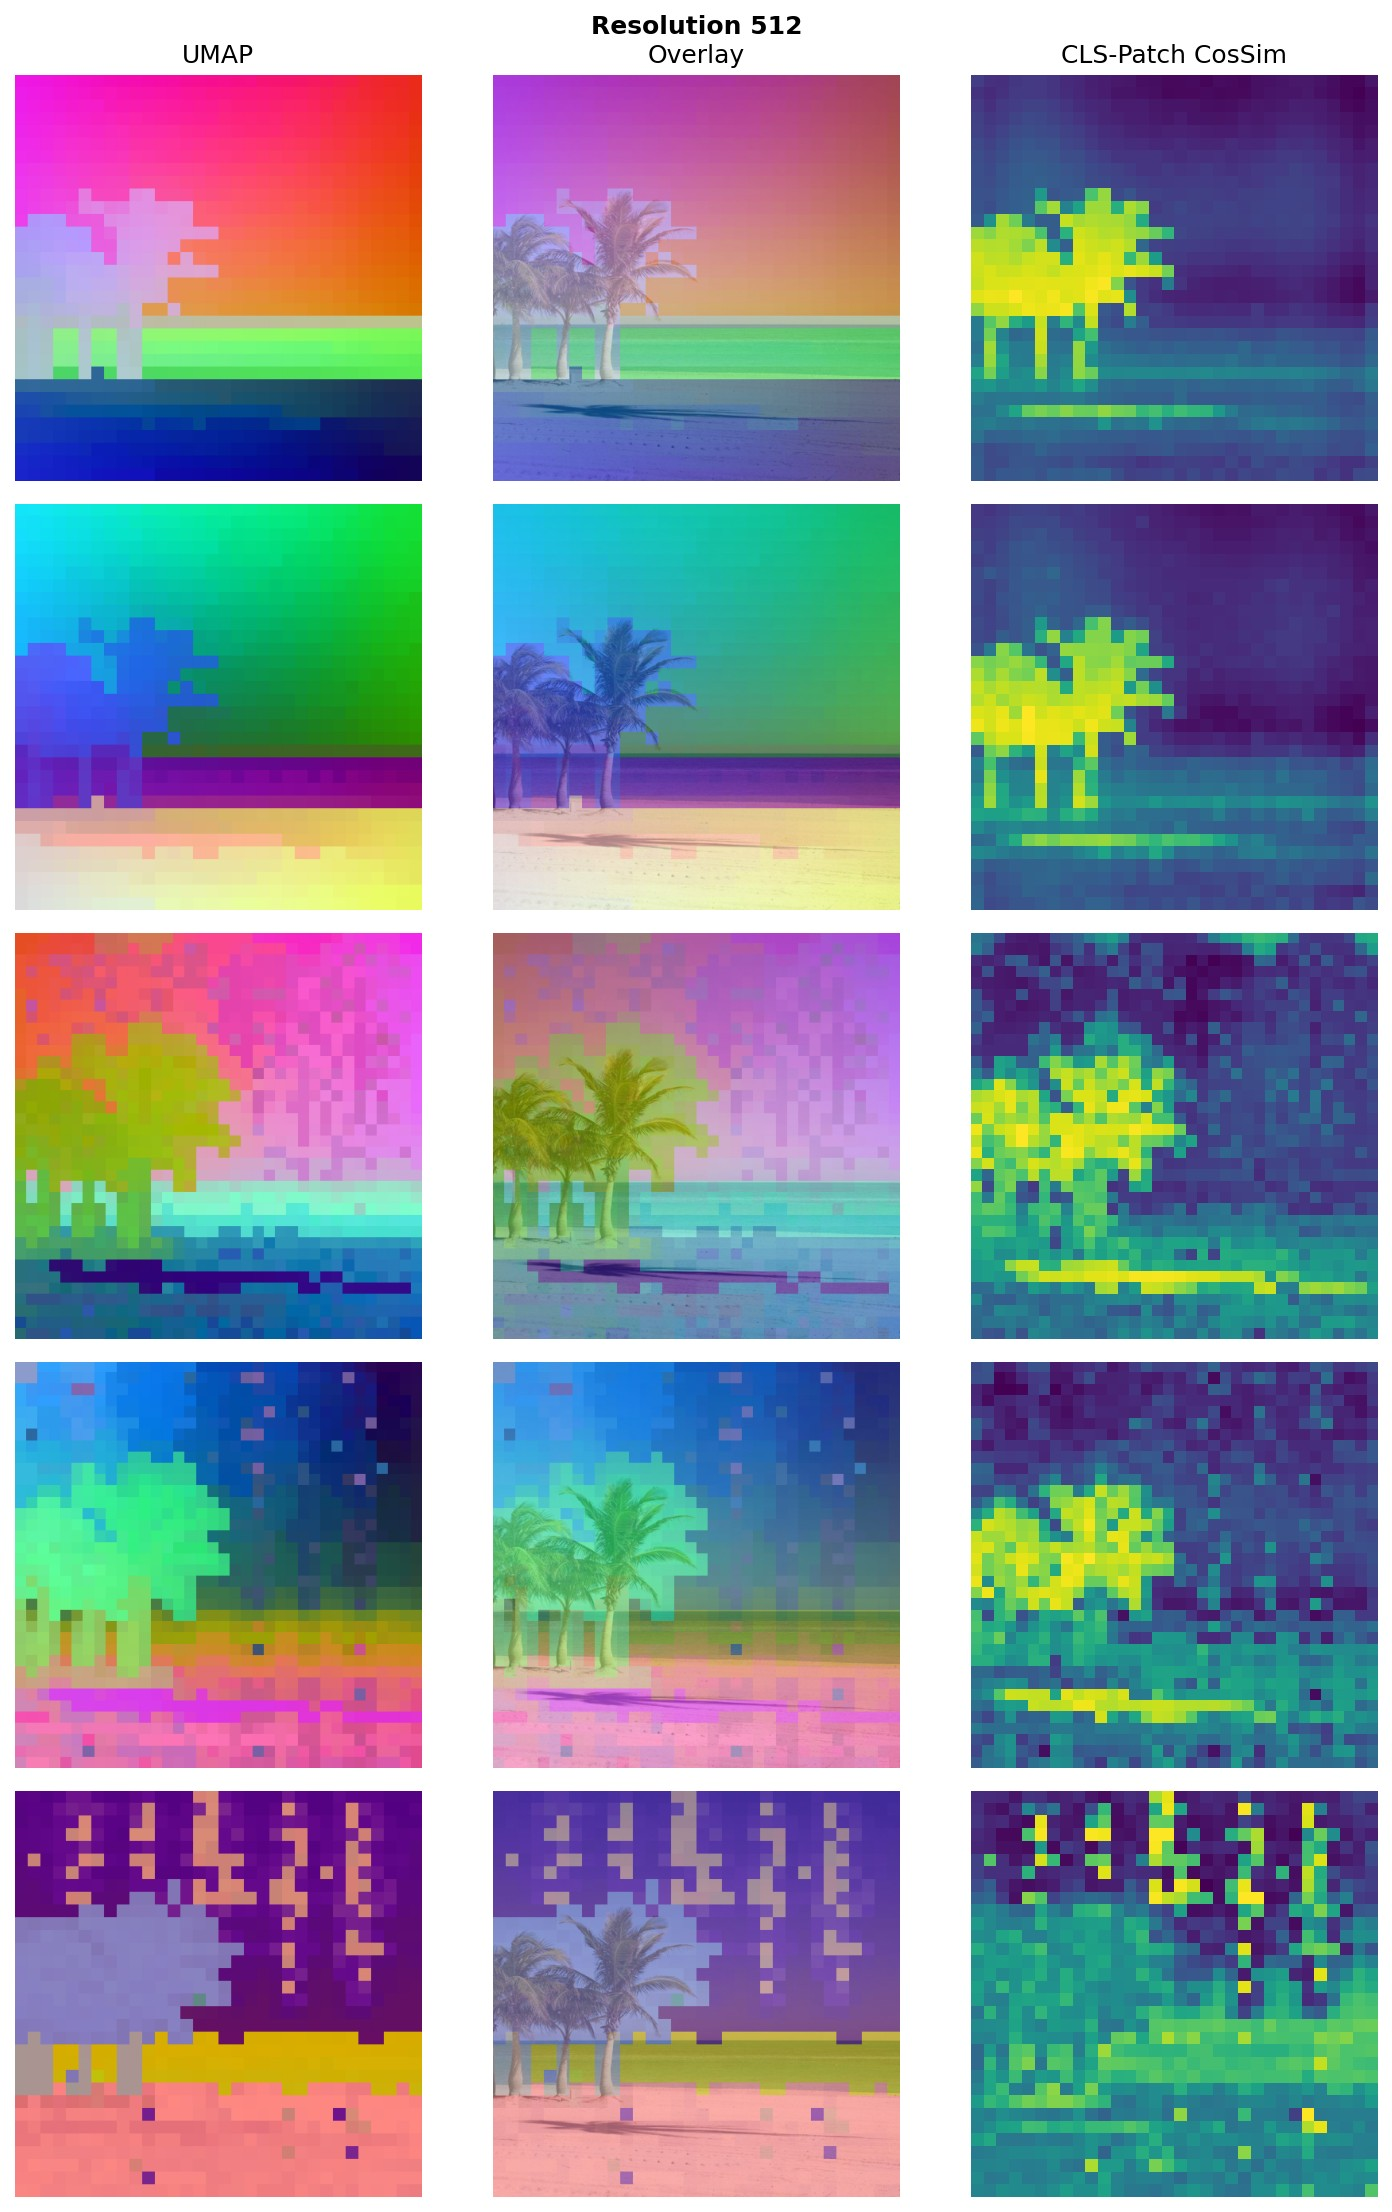

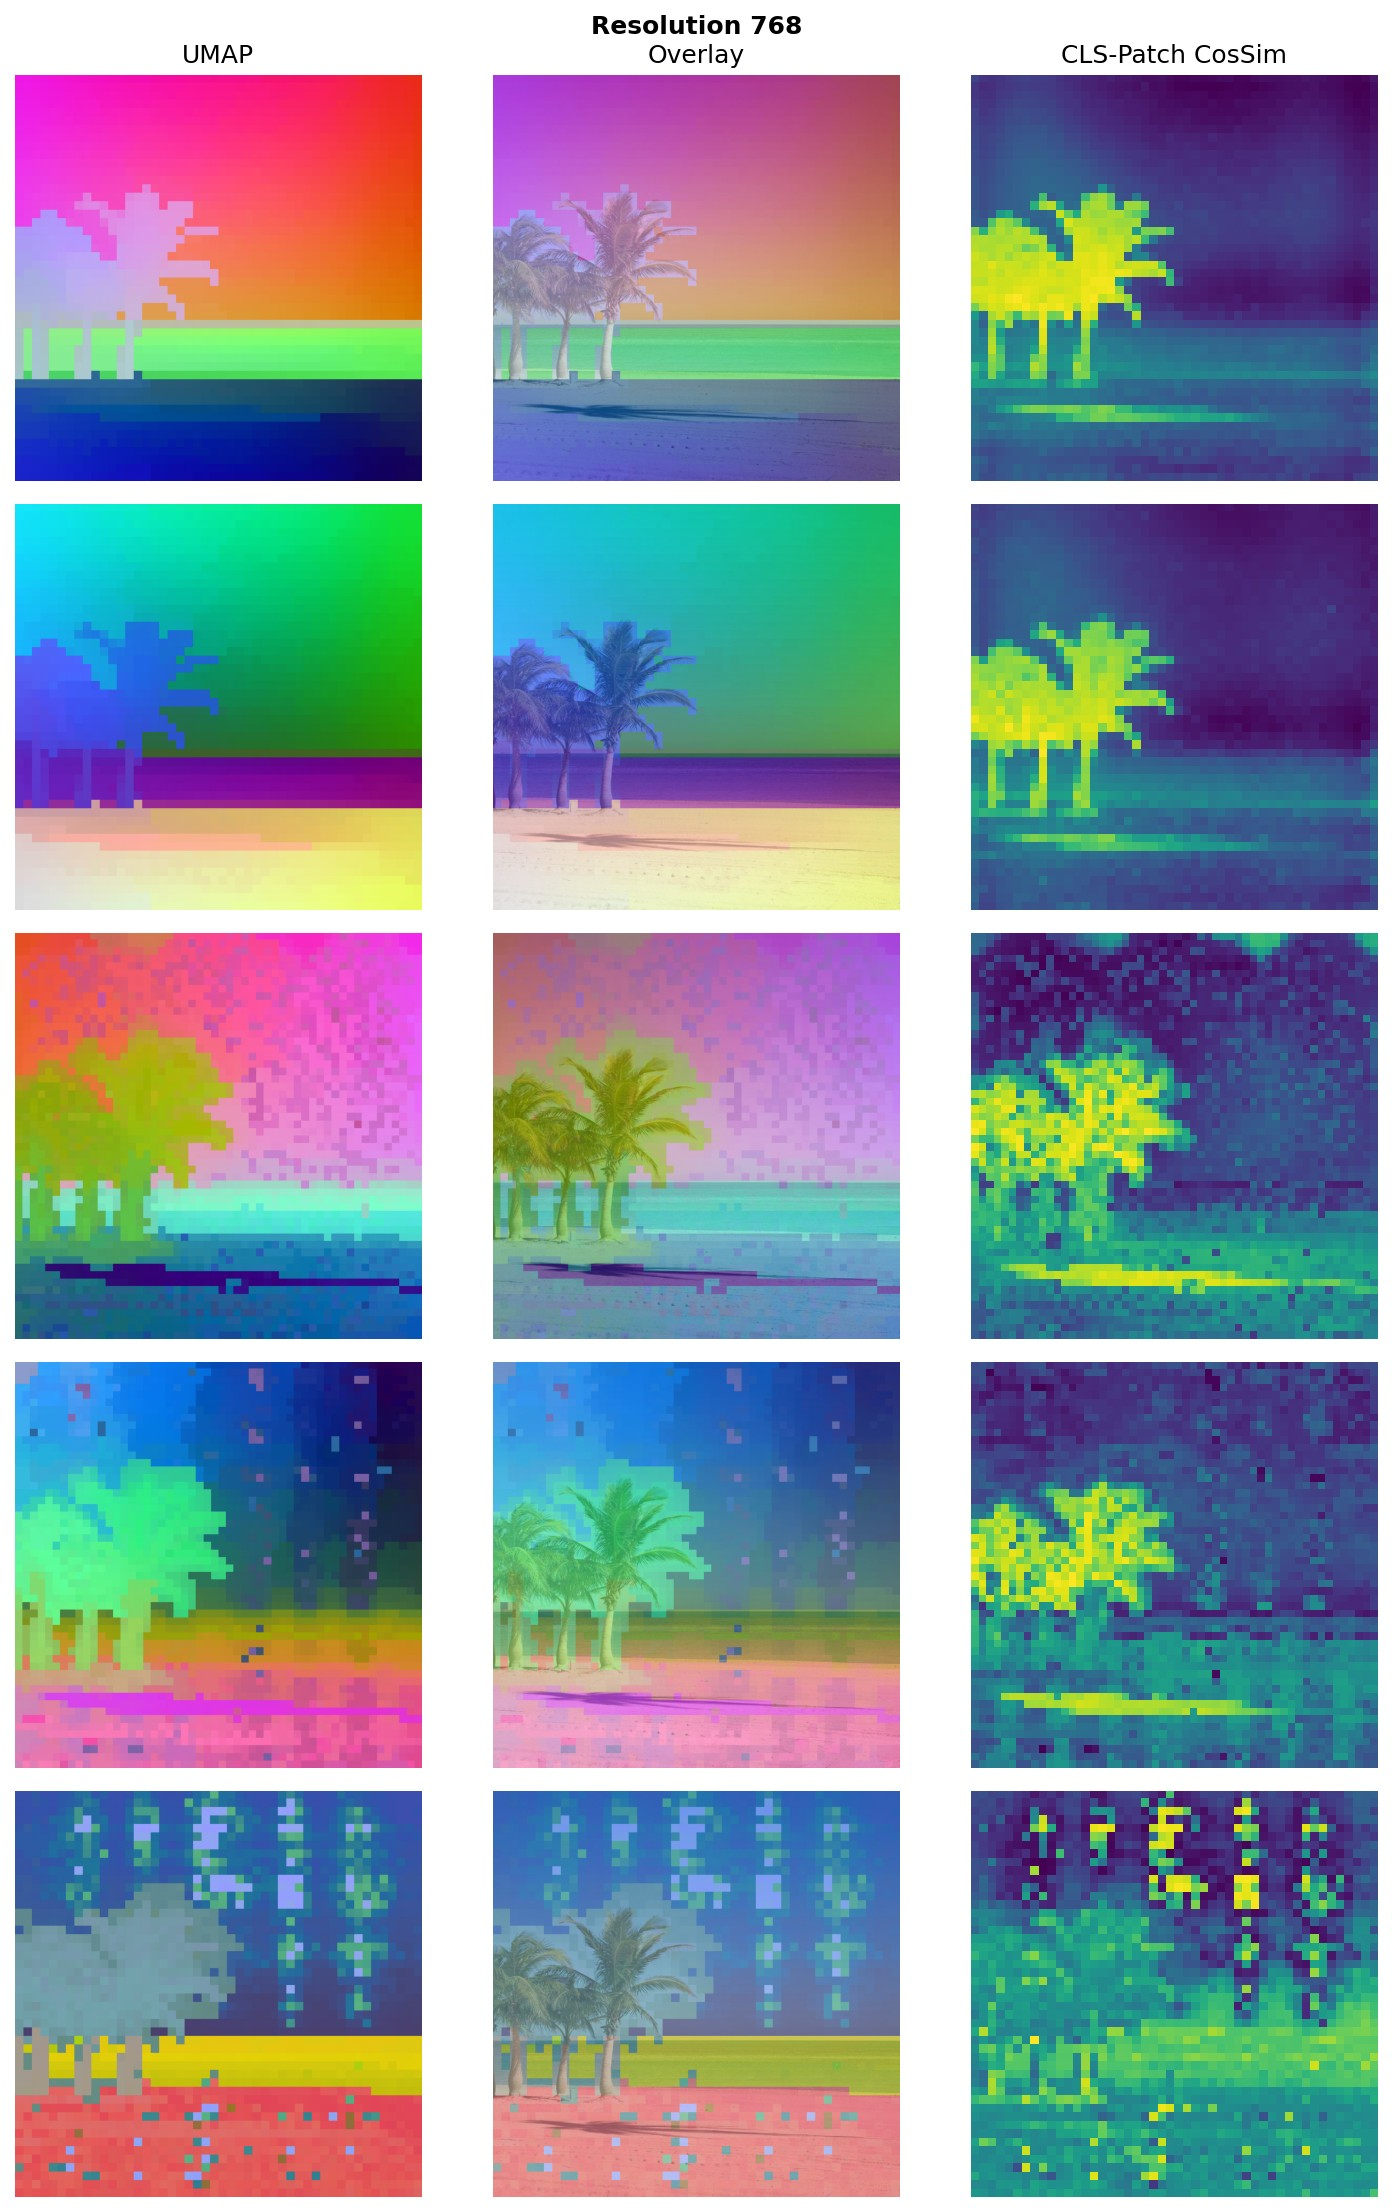

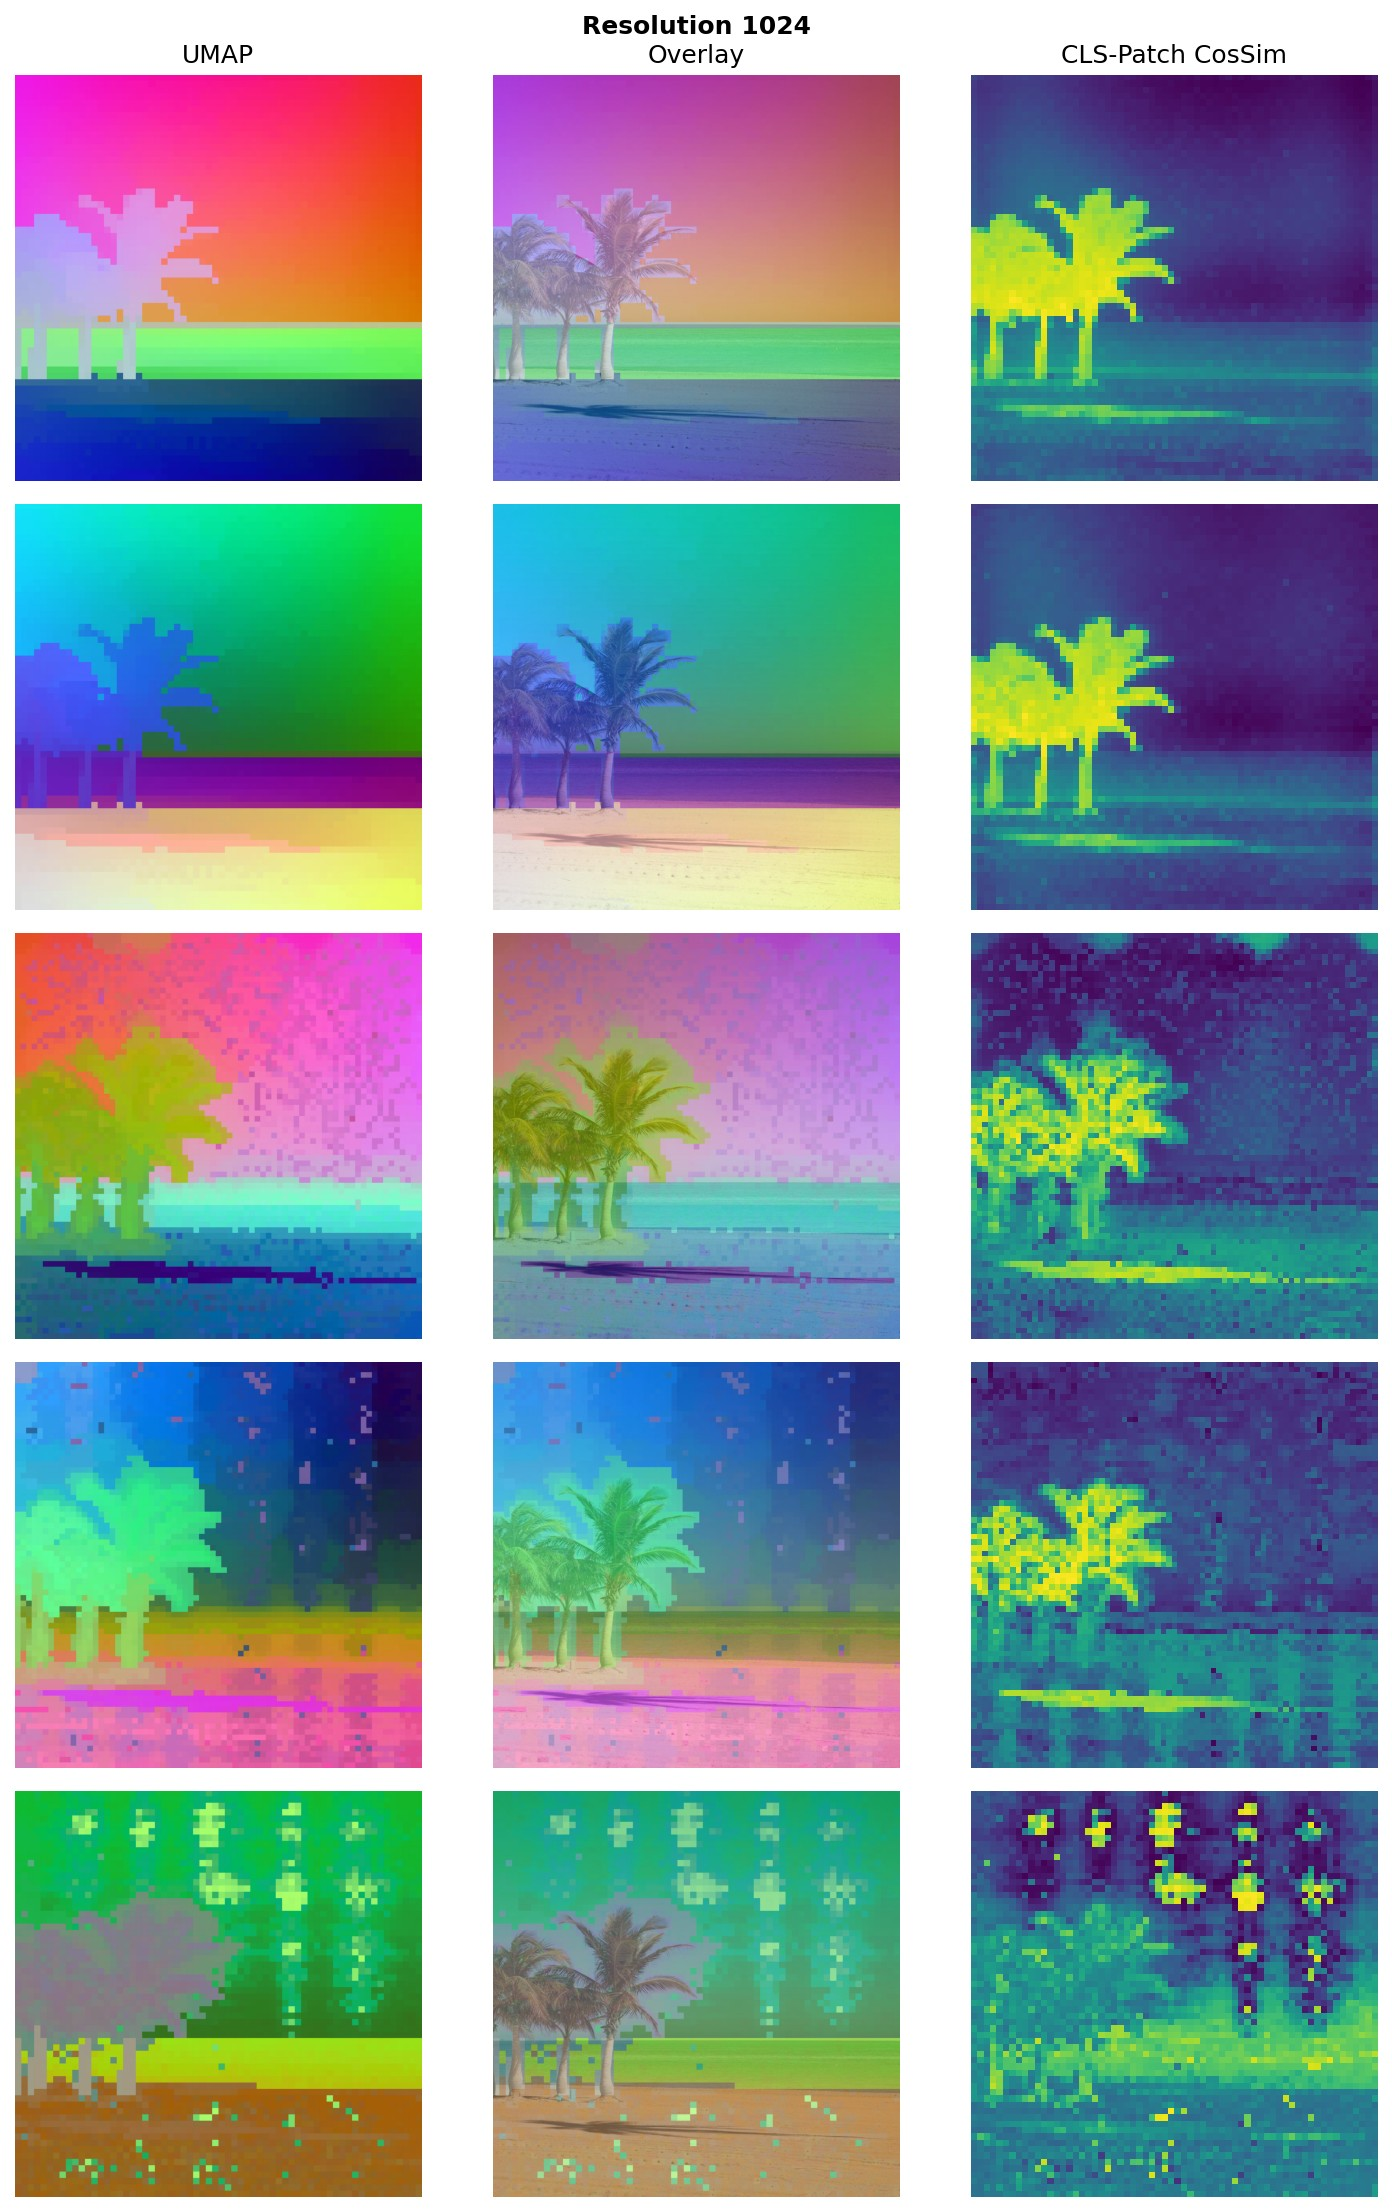

In [12]:
for res in RESOLUTIONS:
    plot_resolution(raw_by_res[res], all_results[res], res)
